# Calvert Island: joining Hakai's observatory to the federal record

**Site.** Calvert Island, central BC coast (51.655 N, 128.126 W). The Hakai Institute runs the
Calvert Island Ecological Observatory here — a met station and tide gauge on the Pruth Bay dock,
an oceanographic mooring in the bay, and a lot else. It is exposed outer coast: Kwakshua Channel
opens west to the Pacific, Fitz Hugh Sound runs east of the island.

**The question.** Hakai publishes its own data on its own ERDDAP server. Fisheries and Oceans
Canada runs a water-level gauge in the same bay, and Environment and Climate Change Canada runs a
lightstation climate record 19 km east. *Can I get all three into one analysable table without
writing three API clients?* That is the case `omnisea` claims to solve, so this notebook works it
end to end: discover, fetch, join, prune, and then do enough real time-series work to find out
whether the numbers survived the trip.

Three organizations, three protocols, three time conventions. Everything below hits the live APIs.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import omnisea

# Third-party deprecations only. omnisea's own warnings stay on — they are how it tells you a
# join is about to go wrong.
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", message=".*numpy.ndarray size changed.*")

pd.set_option("display.width", 150)
pd.set_option("display.max_colwidth", 46)

CALVERT = omnisea.Site(51.655, -128.126, "Calvert Island", radius_km=25)
WINDOW = ("2023-07-01", "2023-08-01")

print("omnisea", omnisea.__version__)
print(CALVERT)

omnisea 0.1.0
Site(lat=51.655, lon=-128.126, name='Calvert Island', radius_km=25, id=None)


## 1. What ERDDAP servers can I reach?

`erddap_servers()` is the starting point: ERDDAP is one piece of software with hundreds of
institutional installations, and omnisea ships short names for eleven of them. Two matter here —
`hakai` is the institute whose station I am standing on, and `cioos_pacific` is where DFO Pacific
publishes its programs.

In [2]:
servers = omnisea.erddap_servers()
print(servers.to_string(index=False))

         server                                               institution                                                                                                                                              holdings  datasets                                     url
   ioos_sensors                      US Integrated Ocean Observing System                                                                 the largest aggregation of US coastal sensors — NDBC buoys, tide gauges, met stations     27260   https://erddap.sensors.ioos.us/erddap
  cioos_pacific               Fisheries and Oceans Canada / CIOOS Pacific                                          DFO Pacific's long-term programs: Line P, C-PROOF gliders, BC lighthouse records, cruise CTD and bottle data       122     https://data.cioospacific.ca/erddap
          hakai                                           Hakai Institute                                                                                       central BC coast m

## 2. Discovery, and the first surprise

Discovery is a separate step from fetching so you can see the size of a query before you make it.
Start with the obvious one: what does Hakai's own server hold within 25 km of Calvert Island for a
month in summer 2023?

In [3]:
import time

t0 = time.perf_counter()
hakai_2023 = omnisea.discover(sites=CALVERT, time=WINDOW,
                              providers="erddap_tabledap", erddap_server="hakai")
print(f"[{time.perf_counter() - t0:.1f} s]")
print(hakai_2023)

[4.7 s]
<Catalog: no stations found for 1 site(s) in Query(position(51.655, -128.126, r=25km), 2023-07-01 00:00Z -> 2023-08-01 00:00Z, variables=all)>
  - erddap_tabledap: nothing matched, but 39 tabledap dataset(s) on https://catalogue.hakai.org/erddap declare no geospatial extent, so no area query can reach them — they are excluded from this catalogue rather than absent from the server. Name them with erddap_datasets=[...] to fetch them anyway.


Nothing. At the Hakai Institute's own field station.

That is not a network failure: the query succeeded and returned an empty `Catalog`, with a hint
about widening the radius. Move the window back to 2020 and the same call finds three datasets, so
the server is answering and the spatial filter works:

In [4]:
t0 = time.perf_counter()
hakai_2020 = omnisea.discover(sites=CALVERT, time=("2020-06-01", "2020-09-01"),
                              providers="erddap_tabledap", erddap_server="hakai")
print(f"[{time.perf_counter() - t0:.1f} s]  {len(hakai_2020)} datasets")
print(hakai_2020.frame[["station_id", "name", "distance_km", "first", "last"]].to_string(index=False))

[0.5 s]  3 datasets
                           station_id                                                                                                                                                name  distance_km                     first                      last
HakaiADCPTimeSeriesProfileProvisional                               Acoustic Doppler Current Profiler Time Series from Fixed Platform on the British Columbia Central Coast (Provisional)     0.000000 2019-02-21 18:29:59+00:00 2020-07-13 00:15:40+00:00
             HakaiCalvertCP1TideGauge                                                                        Water Level Time Series, Choke Pass, Central Coast, BC, Canada (Provisional)     1.775419 2020-01-01 08:00:00+00:00 2021-01-01 07:55:00+00:00
                  HakaiKCBuoyResearch Surface Seawater and Marine Boundary Layer CO2 Observations from the Kwakshua Channel (KC) Buoy on the Central Coast of British Columbia (Research)    11.052183 2018-05-01 15:47:00+00:00 20

The three that show up all declare a time extent that ends in 2020 or 2021. So the filter is doing
what it says — it is the *metadata* that is missing. ERDDAP's `allDatasets` table is what discovery
reads, and Hakai's live Calvert datasets publish no extent in it at all. Check that directly
against the raw server, without omnisea in the way:

In [5]:
import io
import requests

HAKAI = "https://catalogue.hakai.org/erddap"
raw = requests.get(f"{HAKAI}/tabledap/allDatasets.csv"
                   "?datasetID,minLongitude,maxLongitude,minLatitude,maxLatitude,minTime,maxTime",
                   timeout=120)
allds = pd.read_csv(io.StringIO(raw.text), skiprows=[1])
allds = allds[allds.datasetID != "allDatasets"]

no_extent = allds.minTime.isna()
print(f"{len(allds)} datasets on Hakai's ERDDAP; {int(no_extent.sum())} declare no time extent")
print()
print("the ones sitting on Calvert Island:")
print(allds[allds.datasetID.str.contains("Pruth|Calvert|KCBuoy")]
      [["datasetID", "minLatitude", "minLongitude", "minTime", "maxTime"]].to_string(index=False))

62 datasets on Hakai's ERDDAP; 50 declare no time extent

the ones sitting on Calvert Island:
                   datasetID  minLatitude  minLongitude              minTime              maxTime
HakaiPruthMooringProvisional    51.652100   -128.085367                  NaN                  NaN
         HakaiKCBuoyResearch    51.650000   -127.966000 2018-05-01T15:47:00Z 2021-09-03T14:17:00Z
            HakaiKCBuoy1hour    51.649900   -127.966300                  NaN                  NaN
   HakaiPruthDockProvisional    51.654489   -128.130281                  NaN                  NaN
    HakaiCalvertCP1TideGauge    51.670667   -128.121033 2020-01-01T08:00:00Z 2021-01-01T07:55:00Z


`HakaiPruthDockProvisional` and `HakaiPruthMooringProvisional` — the dock met station and the bay
mooring, the two records I actually want — carry `NaN` for both time bounds. Ask the server what
they really cover and it is a very different picture:

In [6]:
for ds in ["HakaiPruthDockProvisional", "HakaiPruthMooringProvisional"]:
    r = requests.get(f'{HAKAI}/tabledap/{ds}.csv?time&orderByMinMax("time")', timeout=180)
    lo, hi = r.text.strip().splitlines()[-2:]
    print(f"{ds:32s} {lo}  ->  {hi}")

HakaiPruthDockProvisional        2014-07-25T00:55:00Z  ->  2026-08-28T12:10:00Z


HakaiPruthMooringProvisional     2017-12-03T03:00:00Z  ->  2024-03-12T18:40:00Z


Twelve years at the dock and six at the mooring, both live through 2023 — invisible to discovery
because the publisher left two metadata fields blank. The README warns about this in general
("a dataset whose publisher declared no extent is invisible to both — name it directly"), and the
escape hatch works, but it is worth being blunt about the consequence: **at this site, on the
server named after the institute that owns the site, discovery finds nothing and you would
reasonably conclude there is no data here.** I only knew to look further because I know the
station exists.

The way through is `erddap_datasets=[...]`, which bypasses the metadata filters. I use it below.

## 3. The multi-server sweep

The interesting claim is that one adapter reaches every ERDDAP installation, so you can ask
several institutions the same question at once. Two forms: a list of servers, and `"all"`.

In [7]:
t0 = time.perf_counter()
pair = omnisea.discover(sites=CALVERT, time=WINDOW, providers="erddap_tabledap",
                        erddap_server=["hakai", "cioos_pacific"])
t_pair = time.perf_counter() - t0

t0 = time.perf_counter()
sweep = omnisea.discover(sites=CALVERT, time=WINDOW, providers="erddap_tabledap",
                         erddap_server="all")
t_all = time.perf_counter() - t0

print(f'erddap_server=["hakai","cioos_pacific"]  {t_pair:5.1f} s   {len(pair):3d} datasets')
print(f'erddap_server="all"  (11 servers)        {t_all:5.1f} s   {len(sweep):3d} datasets')
print(f"errors recorded: {sweep.errors}")
print(f"notes recorded:  {sweep.notes}")

erddap_server=["hakai","cioos_pacific"]    4.5 s    13 datasets
erddap_server="all"  (11 servers)          5.7 s    47 datasets
errors recorded: {}
notes recorded:  {'erddap_tabledap': 'nothing matched, but 5 tabledap dataset(s) on https://salishsea.eos.ubc.ca/erddap declare no geospatial extent, so no area query can reach them — they are excluded from this catalogue rather than absent from the server. Name them with erddap_datasets=[...] to fetch them anyway.; nothing matched, but 1 tabledap dataset(s) on https://nwem.apl.uw.edu/erddap declare no geospatial extent, so no area query can reach them — they are excluded from this catalogue rather than absent from the server. Name them with erddap_datasets=[...] to fetch them anyway.; nothing matched, but 39 tabledap dataset(s) on https://catalogue.hakai.org/erddap declare no geospatial extent, so no area query can reach them — they are excluded from this catalogue rather than absent from the server. Name them with erddap_datasets=[...] to

Both work, and `"all"` is fast — eleven institutions queried concurrently. No server failed today,
so `errors` is empty; the docs say a bad day at one institution is recorded there rather than
passed off as *nothing here*.

Now, which institution did each row come from? That is not in `catalog.frame`. It lives on the
`StationMatch` objects in `catalog.matches`, under `extra["server_name"]`.

**Careful here.** `catalog.frame` and `catalog.matches` are *not in the same order*. Pasting the
matches' server names onto the frame as a column — the obvious move — silently mislabels rows.
I did exactly that on my first pass and spent twenty minutes convinced the library was attributing
CIOOS Pacific datasets to NOAA. Join on `station_id` instead:

In [8]:
print("frame order == matches order?",
      list(sweep.frame.station_id) == [m.station_id for m in sweep.matches])

server_of = {m.station_id: m.extra["server_name"] for m in sweep.matches}
sw = sweep.frame.copy()
sw["server"] = sw.station_id.map(server_of)          # keyed, not positional

print()
print(sw.server.value_counts().to_string())

frame order == matches order? False

server
cioos_pacific      13
coastwatch_west    10
glider_dac          7
ioos_sensors        6
osmc                5
cdip                5
cioos_atlantic      1


Six of eleven servers had something. Now look at what "something" means — and at `distance_km`:

In [9]:
def great_circle_km(lat, lon, lat0=51.655, lon0=-128.126):
    r = 6371.0
    p0, p1 = np.radians(lat0), np.radians(lat)
    a = (np.sin((p1 - p0) / 2) ** 2
         + np.cos(p0) * np.cos(p1) * np.sin(np.radians(lon0 - lon) / 2) ** 2)
    return 2 * r * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

sw["km_from_reported_latlon"] = great_circle_km(sw.lat.values, sw.lon.values).round(0)

print("distinct values of distance_km across the whole sweep:", sorted(sw.distance_km.unique()))
print()
print(sw.sort_values("km_from_reported_latlon", ascending=False)
        .head(12)[["server", "station_id", "lat", "lon",
                   "distance_km", "km_from_reported_latlon"]].to_string(index=False))

distinct values of distance_km across the whole sweep: [np.float64(0.0)]

         server                              station_id  lat  lon  distance_km  km_from_reported_latlon
   ioos_sensors ioos-gliderdac-dfo-eva035-20230620T1434  NaN  NaN          0.0                      NaN
coastwatch_west                   FRDCPSTrawlLHSpecimen  NaN  NaN          0.0                      NaN
coastwatch_west                            erdGtsppBest  NaN  NaN          0.0                      NaN
coastwatch_west                             cwwcNDBCMet  NaN  NaN          0.0                      NaN
coastwatch_west                             nosSosATemp  NaN  NaN          0.0                      NaN
coastwatch_west                             nosSosBPres  NaN  NaN          0.0                      NaN
coastwatch_west                            nosSosWLevel  NaN  NaN          0.0                      NaN
coastwatch_west                             nosSosWTemp  NaN  NaN          0.0                

Every row in the sweep is reported at `distance_km = 0.0`, including a global Argo aggregation and
a dataset of seal-borne profiles. The reason is structural: an ERDDAP dataset declares one bounding
box for the whole collection, Calvert Island falls inside it, and "inside the box" scores as zero.
So for ERDDAP rows `distance_km` answers "does this collection cover my area?", not "how far is the
nearest platform?" — and `filter(nearest=1)` has nothing to sort on.

The `lat`/`lon` columns are honest about this: they are `NaN`. A dataset that spans an ocean has no
single position, and the centre of its bounding box is not one — earlier versions reported that
centre, which put a global Argo collection in Nebraska and, for a collection straddling the
dateline, produced a longitude of about -521 degrees. Unknown is the right answer, and it is the
one the frame gives:


In [10]:
print("distance_km across the whole sweep:", sorted(sw.distance_km.unique()))
print("rows with a known position:", int(sw.lat.notna().sum()), "of", len(sw))
print()
print("A position is reported only where the dataset's extent is a single point -- a fixed")
print("station. Everything else is a track, a grid or a fleet, and says so by saying nothing.")


distance_km across the whole sweep: [np.float64(0.0)]
rows with a known position: 0 of 47

A position is reported only where the dataset's extent is a single point -- a fixed
station. Everything else is a track, a grid or a fleet, and says so by saying nothing.


Read those rows as *"this collection covers your area"* rather than *"there is a station here"* and
the sweep is doing its job. What it is good for is finding **which institution holds relevant
collections**, not which platform is nearest — and on that reading it earned its keep: DFO flies
gliders along the Calvert Island Line every summer, and the sweep shows those deployments
republished on several of these servers under different dataset ids —
because naive de-duplication by id would keep all the copies.

In [11]:
gliders = sw[sw.station_id.str.contains("dfo-", na=False)]
print(f"{len(gliders)} DFO glider deployment datasets, on "
      f"{gliders.server.nunique()} different servers")
print()
print(gliders.groupby("server").station_id.agg(n="size", example="first").to_string())

21 DFO glider deployment datasets, on 3 different servers

               n                                  example
server                                                   
cioos_pacific  8   dfo-eva035-20230620_CTDadjusted_erddap
glider_dac     7                 dfo-eva035-20230620T1434
ioos_sensors   6  ioos-gliderdac-dfo-eva035-20230620T1434


## 4. The federal sources around the island

Now the Canadian government side, where discovery behaves the way the README describes: real
distances, real extents, a printable size estimate.

In [12]:
gov = omnisea.discover(sites=CALVERT, time=WINDOW,
                       providers=["dfo_tides", "eccc_climate_daily", "eccc_climate"])
print(gov)

<Catalog: 6 station(s) from 2 source(s), ~3,627 rows>
            source station_id              name  distance_km  n_rows_est                          variables
         dfo_tides      08863         Pruth Bay         0.24        3100 water_surface_height_above_refere…
         dfo_tides      08866   Starfish Island         3.45         124 water_surface_height_above_refere…
         dfo_tides      08865     Adams Harbour         3.62         124 water_surface_height_above_refere…
eccc_climate_daily    1060080 ADDENBROKE ISLAND        18.98          31 air_temperature, integral_wrt_tim…
         dfo_tides      08860 Addenbroke Island        21.44         124 water_surface_height_above_refere…
         dfo_tides      08912     Spider Island        22.33         124 water_surface_height_above_refere…

  (showing 6 of 14 columns; catalog.frame has them all: provider, site, lat, lon, first, last, server, status)


A DFO water-level gauge called **Pruth Bay (08863)**, 240 m from the site — the same bay as Hakai's
dock. That is the join I want: two agencies measuring the same water, independently, and a chance
to check that omnisea got the datum and the clock right on both.

`ADDENBROKE ISLAND (1060080)` is the ECCC lightstation, 19 km east in Fitz Hugh Sound. It is the
closest federal air-temperature record, and it is on the other side of the island from the Pacific
swell — remember that when the numbers come in.

Two gaps worth noting before fetching: DFO rows come back with `first`/`last` as `NaT`, so there is
no way to tell from the catalogue whether a gauge was actually operating in my window; and
`n_rows_est` for a station like Pruth Bay is a per-day heuristic rather than a query.

In [13]:
print(gov.frame[["source", "station_id", "name", "distance_km", "n_rows_est", "first", "last"]]
      .head(6).to_string(index=False))

            source station_id              name  distance_km  n_rows_est                     first                      last
         dfo_tides      08863         Pruth Bay     0.244642        3100                       NaT                       NaT
         dfo_tides      08866   Starfish Island     3.453250         124                       NaT                       NaT
         dfo_tides      08865     Adams Harbour     3.624997         124                       NaT                       NaT
eccc_climate_daily    1060080 ADDENBROKE ISLAND    18.977523          31 1978-01-01 00:00:00+00:00 2026-06-21 00:00:00+00:00
         dfo_tides      08860 Addenbroke Island    21.440267         124                       NaT                       NaT
         dfo_tides      08912     Spider Island    22.329348         124                       NaT                       NaT


## 5. Fetch: three organizations, one call

Named Hakai datasets (to get past the missing extents), plus DFO tides and ECCC daily climate.
`depth=[0.0, 0.0]` restricts the mooring to its surface sensor — section 6 explains why that is not
optional.

In [14]:
t0 = time.perf_counter()
tree = omnisea.fetch(
    sites=CALVERT, time=WINDOW,
    providers=["erddap_tabledap", "dfo_tides", "eccc_climate_daily"],
    erddap_server="hakai",
    erddap_datasets=["HakaiPruthDockProvisional", "HakaiPruthMooringProvisional"],
    depth=[0.0, 0.0],
)
print(f"[{time.perf_counter() - t0:.1f} s]")
print(omnisea.describe(tree).to_string(index=False))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T12:28:31+00:00 from 3 source(s) across 7 station(s), covering 2023-07-01 to 2023-08-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (4 station(s), 2023-07-01 to 2023-08-01): Pruth Bay (08863), Addenbroke Island (08860), Adams Harbour (08865), Spider Island (08912). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate_daily (1 station(s), 2023-07-01 to 2023-08-01): ADDENBROKE ISLAND (1060080). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Hakai Institute — erddap_tabledap (1 station(s), 2023-07-01 to 2023-08-01): Water Level and Weather Station Time Series, Pruth Bay, Kwakshua Channel, Central Coast, BC, Canada (Provisional) (HakaiPr

Seven nodes from three organizations. Observations and harmonic predictions are in separate
branches, which matters: `/in_situ/tides/08863` is a measurement, `/predictions/tides_hilo/08865`
is a model, and in a flat table they would look identical.

Provenance comes out of the result rather than out of memory:

In [15]:
print(omnisea.provenance(tree)[["provider", "source", "institution", "license",
                                "n_stations", "n_values"]].to_string(index=False))

provider             source                                                              institution                                                                  license  n_stations  n_values
     dfo          dfo_tides              Fisheries and Oceans Canada / Canadian Hydrographic Service           Fisheries and Oceans Canada — Open Government Licence – Canada           4      3333
    eccc eccc_climate_daily Environment and Climate Change Canada / Meteorological Service of Canada Environment and Climate Change Canada — Open Government Licence – Canada           1        32
  erddap    erddap_tabledap                                                          Hakai Institute                              https://creativecommons.org/licenses/by/4.0           1      8929
  erddap    erddap_tabledap                                                          Hakai Institute                              https://creativecommons.org/licenses/by/4.0           1      8929


## 6. Before trusting any of it: units, clocks, and depths

Three sources, three vocabularies. `fields()` reports what each one actually published rather than
a hardcoded table, which is what makes the next step possible:

In [16]:
f = omnisea.fields(tree)
look = ["airtemp_avg", "air_temperature", "air_temperature_max", "sea_water_temperature",
        "tideheight_avg", "water_surface_height_above_reference_datum",
        "windspd_avg", "precipitation_amount", "par_avg"]
print(f[f.variable.isin(look)][["variable", "standard_name", "units", "cell_methods", "source"]]
      .drop_duplicates("variable").to_string(index=False))

par = tree["/in_situ/erddap/hakai/HakaiPruthDockProvisional"].dataset.par_avg
print()
print(f"Hakai par_avg ranges {np.nanmin(par.values):.1f} to {np.nanmax(par.values):.1f} "
      f"{par.attrs['units']}")

                                  variable                                         standard_name           units                       cell_methods             source
                               airtemp_avg                                       air_temperature degrees_celsius time: mean (interval: 5.0 minutes)    erddap_tabledap
                                   par_avg surface_downwelling_photosynthetic_photon_flux_in_air     mol m-2 s-1 time: mean (interval: 5.0 minutes)    erddap_tabledap
                               windspd_avg                                            wind_speed             m/s time: mean (interval: 5.0 minutes)    erddap_tabledap
                            tideheight_avg                                                                     m time: mean (interval: 5.0 minutes)    erddap_tabledap
                     sea_water_temperature                                 sea_water_temperature  degree_Celsius                                       erddap_tableda

### One mooring, twelve instruments

The Pruth Bay mooring reports every depth on the same clock. A tabledap response is therefore
*not* one time series, and treating it as one means twelve rows compete for each timestamp with
only one surviving — which is what omnisea used to do, silently discarding 91.7% of the rows and
leaving a `sea_water_temperature` column that wandered between 0 m and 60 m, 8 degC to 14 degC,
looking exactly like an ordinary series.

The dataset says how to tell its rows apart: `cdm_timeseries_variables = station,latitude,longitude,depth`.
omnisea reads that and splits accordingly.


In [17]:
loose = omnisea.fetch(sites=CALVERT, time=("2023-07-01", "2023-07-02"),
                      providers="erddap_tabledap", erddap_server="hakai",
                      erddap_datasets=["HakaiPruthMooringProvisional"])

nodes = {p.split("/")[-1]: ds for p, ds in omnisea.tree.data_nodes(loose)}
print(f"{len(nodes)} nodes from one dataset:", ", ".join(nodes))
print()
rows = []
for name, ds in nodes.items():
    d = pd.unique(ds.depth.values[~np.isnan(ds.depth.values)])
    t = ds.sea_water_temperature.to_series()
    rows.append({"node": name, "depth_m": float(d[0]), "n_time": ds.sizes["time"],
                 "mean_degC": round(float(t.mean()), 2)})
print(pd.DataFrame(rows).to_string(index=False))
print()
print(f"total points kept: {sum(r['n_time'] for r in rows):,}")


Data were retrieved with omnisea 0.1.0 on 2026-08-28T12:28:32+00:00 from 1 source(s) across 12 station(s), covering 2023-07-01 to 2023-07-02.

  Hakai Institute — erddap_tabledap (12 station(s), 2023-07-01 to 2023-07-02): Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_0 (HakaiPruthMooringProvisional:depth_0), Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_10 (HakaiPruthMooringProvisional:depth_10), Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_15 (HakaiPruthMooringProvisional:depth_15), Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_2 (HakaiPruthMooringProvisional:depth_2), Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_20 (HakaiPruthMooringProvisional:depth_20), Pruth Bay Oceanographic Mooring on Calvert Island (Provisional) — depth_25 (HakaiPruthMooringProvisional:depth_25) and 6 more. Licence: https://creativecommons.org/licenses/by/4.0. Terms: https://catalo

Twelve nodes, one per instrument, each at a single constant depth and each holding the full
289-sample day — and the temperatures fall in the order the physics demands, warm at the surface
and cold at 60 m. Check the total against the raw server:


In [18]:
r = requests.get(f"{HAKAI}/tabledap/HakaiPruthMooringProvisional.csv"
                 "?time,depth,watertemp&time>=2023-07-01T00:00:00Z&time<2023-07-02T00:00:00Z",
                 timeout=180)
upstream = pd.read_csv(io.StringIO(r.text), skiprows=[1], parse_dates=["time"])

kept = sum(ds.sizes["time"] for _, ds in omnisea.tree.data_nodes(loose))
print(f"upstream rows for 1 July 2023 : {len(upstream):,}")
print(f"rows kept across the 12 nodes : {kept:,}")
print()
print("upstream at 2023-07-01T00:00Z, all depths:")
print(upstream[upstream.time == "2023-07-01T00:00:00Z"][["depth", "watertemp"]].to_string(index=False))


upstream rows for 1 July 2023 : 3,456
rows kept across the 12 nodes : 3,468

upstream at 2023-07-01T00:00Z, all depths:
 depth  watertemp
     0     14.050
     2     13.353
     5     11.005
     7     10.222
    10      9.657
    15      8.444
    20      8.369
    25      8.045
    30      7.494
    40      9.657
    50      7.368
    60      7.293


Every row upstream is a row in the tree. The profile is preserved because the *dataset* said how to
tell its rows apart and omnisea read that, rather than assuming one table means one series.

Where a dataset does not say — DFO's `IOS_CUR_Moorings` declares only `profile` while publishing two
current meters 80 m apart — omnisea looks for a discriminator among the columns the response
actually carries, and if it finds none it warns rather than keeping one row per instant at random.

For the rest of this notebook I want a single level, so the main `tree` asks for one with
`depth=[low, high]` at fetch time. The split only fires where there is something to split, so that
request comes back as one node. (Passing a single value, `depth=[0.0]`, raises a bare `IndexError`
from inside the library rather than telling you the argument is a range.)


In [19]:
moor = tree["/in_situ/erddap/hakai/HakaiPruthMooringProvisional"].dataset
depths = pd.unique(moor.depth.values[~np.isnan(moor.depth.values)])
print(f"depths in the analysis node: {depths}   n_time = {moor.sizes['time']}")
print()
print("Asking for one depth range gives one node -- the split only fires where there is")
print("something to split, so a single-level request is unchanged.")


depths in the analysis node: [0.]   n_time = 8929

Asking for one depth range gives one node -- the split only fires where there is
something to split, so a single-level request is unchanged.


### Spot-check the numbers against the upstream APIs

Metadata aside, are the *values* the values? Pick three timestamps and compare each node against
the API it came from, queried by hand.

In [20]:
STAMPS = pd.to_datetime(["2023-07-15T12:00:00", "2023-07-15T12:15:00", "2023-07-20T06:00:00"])

def series(node_path, var):
    ds = tree[node_path].dataset
    return pd.Series(ds[var].values, index=pd.to_datetime(ds.time.values))

# --- DFO IWLS, queried directly at 15-minute resolution
iwls = requests.get("https://api-iwls.dfo-mpo.gc.ca/api/v1/stations/"
                    "5dd30650e0fdc4b9b4be6dfe/data",
                    params={"time-series-code": "wlo", "resolution": "FIFTEEN_MINUTES",
                            "from": "2023-07-15T11:00:00Z", "to": "2023-07-20T07:00:00Z"},
                    timeout=180).json()
iwls = pd.DataFrame(iwls)
iwls["eventDate"] = pd.to_datetime(iwls.eventDate).dt.tz_localize(None)
iwls = iwls.set_index("eventDate")["value"]

# --- Hakai ERDDAP, queried directly
rd = requests.get(f"{HAKAI}/tabledap/HakaiPruthDockProvisional.csv"
                  "?time,airtemp_avg,tideheight_avg"
                  "&time>=2023-07-15T12:00:00Z&time<=2023-07-20T06:00:00Z", timeout=180)
dock_raw = pd.read_csv(io.StringIO(rd.text), skiprows=[1], parse_dates=["time"]).set_index("time")
dock_raw.index = dock_raw.index.tz_localize(None)

rm = requests.get(f"{HAKAI}/tabledap/HakaiPruthMooringProvisional.csv"
                  "?time,depth,watertemp&depth=0"
                  "&time>=2023-07-15T12:00:00Z&time<=2023-07-20T06:00:00Z", timeout=180)
moor_raw = pd.read_csv(io.StringIO(rm.text), skiprows=[1], parse_dates=["time"]).set_index("time")
moor_raw.index = moor_raw.index.tz_localize(None)

check = pd.DataFrame({
    "dfo_wl_omnisea":   series("/in_situ/tides/08863",
                               "water_surface_height_above_reference_datum").reindex(STAMPS),
    "dfo_wl_upstream":  iwls.reindex(STAMPS),
    "hakai_tide_omnisea":  series("/in_situ/erddap/hakai/HakaiPruthDockProvisional",
                                  "tideheight_avg").reindex(STAMPS),
    "hakai_tide_upstream": dock_raw.tideheight_avg.reindex(STAMPS),
    "hakai_airT_omnisea":  series("/in_situ/erddap/hakai/HakaiPruthDockProvisional",
                                  "airtemp_avg").reindex(STAMPS),
    "hakai_airT_upstream": dock_raw.airtemp_avg.reindex(STAMPS),
    "hakai_seaT_omnisea":  series("/in_situ/erddap/hakai/HakaiPruthMooringProvisional",
                                  "sea_water_temperature").reindex(STAMPS),
    "hakai_seaT_upstream": moor_raw.watertemp.reindex(STAMPS),
})
print(check.T.to_string())
print()
for a, b in [("dfo_wl", "dfo_wl"), ("hakai_tide", "hakai_tide"),
             ("hakai_airT", "hakai_airT"), ("hakai_seaT", "hakai_seaT")]:
    d = (check[f"{a}_omnisea"] - check[f"{b}_upstream"]).abs().max()
    print(f"{a:12s} max |omnisea - upstream| = {d:.6f}")

                     2023-07-15 12:00:00  2023-07-15 12:15:00  2023-07-20 06:00:00
dfo_wl_omnisea                     1.205                1.060                2.638
dfo_wl_upstream                    1.205                1.060                2.638
hakai_tide_omnisea                 1.211                1.078                2.617
hakai_tide_upstream                1.211                1.078                2.617
hakai_airT_omnisea                12.510               12.490               14.210
hakai_airT_upstream               12.510               12.490               14.210
hakai_seaT_omnisea                15.796               15.772               14.457
hakai_seaT_upstream               15.796               15.772               14.457

dfo_wl       max |omnisea - upstream| = 0.000000
hakai_tide   max |omnisea - upstream| = 0.000000
hakai_airT   max |omnisea - upstream| = 0.000000
hakai_seaT   max |omnisea - upstream| = 0.000000


Identical to the last decimal, on the same UTC stamps, from two protocols. And the ECCC daily
record, checked the same way:

In [21]:
ecc = requests.get("https://api.weather.gc.ca/collections/climate-daily/items",
                   params={"CLIMATE_IDENTIFIER": "1060080", "datetime": "2023-07-01/2023-07-03",
                           "f": "json", "limit": 5}, timeout=120).json()
up = pd.DataFrame([{"date": p["properties"]["LOCAL_DATE"][:10],
                    "MEAN": p["properties"]["MEAN_TEMPERATURE"],
                    "MAX": p["properties"]["MAX_TEMPERATURE"],
                    "MIN": p["properties"]["MIN_TEMPERATURE"],
                    "PRECIP": p["properties"]["TOTAL_PRECIPITATION"]}
                   for p in ecc["features"]]).set_index("date").sort_index()

e = tree["/in_situ/weather_daily/1060080"].dataset
om = pd.DataFrame({"MEAN": e.air_temperature.values, "MAX": e.air_temperature_max.values,
                   "MIN": e.air_temperature_min.values,
                   "PRECIP": e.precipitation_amount.values},
                  index=pd.to_datetime(e.time.values).strftime("%Y-%m-%d")).loc[up.index]

print("upstream api.weather.gc.ca:"); print(up.to_string())
print(); print("omnisea node:"); print(om.to_string())
print(); print("max abs difference:", float((om - up).abs().to_numpy().max()))

upstream api.weather.gc.ca:
            MEAN   MAX   MIN  PRECIP
date                                
2023-07-01  14.0  16.5  11.5     4.2
2023-07-02  14.8  18.0  11.5     0.0
2023-07-03  16.5  21.5  11.5     0.0

omnisea node:
            MEAN   MAX   MIN  PRECIP
date                                
2023-07-01  14.0  16.5  11.5     4.2
2023-07-02  14.8  18.0  11.5     0.0
2023-07-03  16.5  21.5  11.5     0.0

max abs difference: 0.0


Matching too — and note the node records the convention explicitly, which is the part that usually
bites:

In [22]:
print(e.attrs["time_reference"])
print()
print("node stamps:", pd.to_datetime(e.time.values)[:3].strftime("%Y-%m-%d %H:%MZ").tolist())
midrange = (up.MAX.astype(float) + up.MIN.astype(float)) / 2
print("ECCC MEAN vs (MAX+MIN)/2, max difference:",
      float((up.MEAN.astype(float) - midrange).abs().max()), "degC")

LOCAL_DATE: daily aggregates are labelled by local calendar date and stamped at 00:00Z. climate-daily publishes no UTC_DATE, so no offset is applied here.

node stamps: ['2023-07-01 00:00Z', '2023-07-02 00:00Z', '2023-07-03 00:00Z']
ECCC MEAN vs (MAX+MIN)/2, max difference: 0.05000000000000071 degC


So the ECCC daily "mean" is `(max + min) / 2` rounded to a tenth — a mid-range statistic on a local
calendar day, stamped at 00:00Z, not a 24-hour average. Hakai
is a true 5-minute record in UTC. They are not the same kind of number, and section 11 quantifies
how far apart that puts them.

## 7. Joining onto my own irregular timestamps

Our shore crew works the low tides. The realistic sampling schedule is not a regular grid, it is
"whenever the water is out", which the harmonic prediction gives me: 59 predicted low waters in the
month at Adams Harbour (08865), the nearest station with a prediction series. I build a field sheet
from those times and carry the predicted low height as my own column, then ask omnisea to hang
every other source off it.

In [23]:
ext = tree["/predictions/tides_hilo/08865"].dataset
extrema = pd.Series(ext.water_surface_height_above_reference_datum_at_extremum.values,
                    index=pd.to_datetime(ext.time.values)).dropna()

v = extrema.to_numpy()
is_low = np.r_[False, (v[1:-1] < v[:-2]) & (v[1:-1] < v[2:]), False]
lows = extrema[is_low]

sheet = pd.DataFrame({"time": lows.index.tz_localize("UTC"), "pred_low_m": lows.to_numpy()})
print(f"{len(extrema)} predicted extrema in the month -> {len(sheet)} low waters")
print(sheet.head(4).to_string(index=False))
print("median interval between low waters:",
      sheet.time.diff().median())

120 predicted extrema in the month -> 59 low waters
                     time  pred_low_m
2023-07-01 13:13:00+00:00       0.570
2023-07-02 00:54:00+00:00       2.035
2023-07-02 14:01:00+00:00       0.296
2023-07-03 01:44:00+00:00       1.961
median interval between low waters: 0 days 12:21:30


In [24]:
X = omnisea.align(tree, on=sheet, tolerance="30min")

show = ["pred_low_m", "water_surface_height_above_reference_datum", "tideheight_avg",
        "sea_water_temperature", "airtemp_avg", "air_temperature", "windspd_avg",
        "precipitation_amount"]
print("shape:", X.shape)
print(X[show].head(8).round(3).to_string())

shape: (59, 62)
                     pred_low_m  water_surface_height_above_reference_datum  tideheight_avg  sea_water_temperature  airtemp_avg  air_temperature  windspd_avg  precipitation_amount
time                                                                                                                                                                               
2023-07-01 13:13:00       0.570                                       0.635           0.639                 13.137        12.02             14.0        1.406                   4.2
2023-07-02 00:54:00       2.035                                       1.993           1.977                 13.402        14.56             14.0        1.589                   4.2
2023-07-02 14:01:00       0.296                                       0.298           0.304                 12.316        11.24             14.8        0.000                   0.0
2023-07-03 01:44:00       1.961                                       1.923         

My column survives the join, so response and predictors are in one frame. The interesting part is
the audit trail — every column records *how* it was matched, and the rule differs by variable
because the CF `cell_methods` differ:

In [25]:
for k in show:
    if k in X.attrs["omnisea_aggregation"]:
        print(f"{k:44s} {X.attrs['omnisea_aggregation'][k]}")

water_surface_height_above_reference_datum   nearest within 30min (59/59 matched)
tideheight_avg                               backward within its own 5min interval (59/59 matched)
sea_water_temperature                        nearest within 30min (59/59 matched)
airtemp_avg                                  backward within its own 5min interval (59/59 matched)
air_temperature                              backward within its own 1d interval (59/59 matched), read in station-local time (America/Vancouver)
windspd_avg                                  backward within its own 5min interval (59/59 matched)
precipitation_amount                         backward within its own 1d interval (59/59 matched), read in station-local time (America/Vancouver)


Read that carefully, because it is doing real work:

- DFO's water level and the mooring temperature are **instantaneous**, so they match to the
  *nearest* reading within 30 minutes.
- Hakai's dock variables are 5-minute **interval summaries**, so they match *backwards within their
  own interval* — a sample at 13:13 gets the 13:10-13:15 bin, not the nearest stamp.
- ECCC's daily total gets the day *containing* the sample, read in `America/Vancouver`. That is the
  one that would otherwise be quietly wrong: a 30-minute tolerance against a value stamped at
  midnight matches nothing, and a UTC reading of a local calendar date is off by seven hours in
  July.

All 59 rows matched on every column. If some had not, the count would say so instead of leaving me
to infer it from `NaN`s.

## 8. Joining onto a regular grid

The same tree, resampled to hourly. Downsampling Hakai's 5-minute data and upsampling ECCC's daily
data happen in one call, each by its own `cell_methods` rule.

In [26]:
H = omnisea.align(tree, freq="1h")
print("hourly matrix:", H.shape)

daily_cols = ["air_temperature", "precipitation_amount"]
print()
print(H[["water_surface_height_above_reference_datum", "tideheight_avg", "airtemp_avg",
         "sea_water_temperature", "air_temperature"]].iloc[:10].round(3).to_string())

hourly matrix: (752, 61)

                     water_surface_height_above_reference_datum  tideheight_avg  airtemp_avg  sea_water_temperature  air_temperature
time                                                                                                                                
2023-07-01 00:00:00                                       2.080           2.084       15.188                 14.147              NaN
2023-07-01 01:00:00                                       2.327           2.348       14.854                 14.285              NaN
2023-07-01 02:00:00                                       2.806           2.833       14.400                 14.275              NaN
2023-07-01 03:00:00                                       3.396           3.429       14.182                 14.197              NaN
2023-07-01 04:00:00                                       3.971           3.994       12.875                 14.129              NaN
2023-07-01 05:00:00                        

The first seven hours of the ECCC columns are `NaN`, and that is correct rather than broken. The
daily value labelled 1 July is a *local* calendar day; localized to `America/Vancouver` it starts at
07:00Z. Hours 00:00Z-06:00Z on 1 July belong to 30 June, which I did not fetch. Count them:

In [27]:
gap = int(H.air_temperature.isna().sum())
print(f"NaN hours in the ECCC column: {gap}")
print(f"UTC offset at Addenbroke Island in July: "
      f"{-pd.Timestamp('2023-07-01', tz='America/Vancouver').utcoffset().total_seconds() / 3600:.0f} h")
print()
print(H.air_temperature.iloc[4:10].to_string())

NaN hours in the ECCC column: 7
UTC offset at Addenbroke Island in July: 7 h

time
2023-07-01 04:00:00     NaN
2023-07-01 05:00:00     NaN
2023-07-01 06:00:00     NaN
2023-07-01 07:00:00    14.0
2023-07-01 08:00:00    14.0
2023-07-01 09:00:00    14.0
Freq: h


Exactly the offset, no more. A library that read the daily stamp as UTC would have shown no gap at
all and been seven hours wrong all month — the failure that leaves no trace.

## 9. What moves together across the three sources?

A matrix assembled from three organizations is collinear by construction: some pairs are the same
physical quantity measured twice, some are derived from each other. `correlations()` reports the
pairs above threshold with the overlap `n` each was computed on.

In [28]:
KEEP = ["water_surface_height_above_reference_datum",           # DFO   observed water level
        "tideheight_avg", "tideheight_med",                     # Hakai dock tide gauge
        "sea_water_temperature",                                # Hakai mooring, 0 m
        "airtemp_avg", "rh_avg", "windspd_avg",                 # Hakai dock met
        "stationairpressure_avg", "sealevelairpressure_avg",
        "solarrad_avg", "par_avg", "hourlyrain",
        "air_temperature", "air_temperature_max", "air_temperature_min",   # ECCC daily
        "precipitation_amount", "heating_degree_days", "cooling_degree_days"]

K = H[[c for c in KEEP if c in H.columns]]
print("candidate predictors:", K.shape)
print()
print(omnisea.correlations(K).to_string(index=False))

candidate predictors: (752, 18)

                                 feature_a               feature_b         r   n
                    stationairpressure_avg sealevelairpressure_avg  1.000000 745
                            tideheight_avg          tideheight_med  0.999922 745
water_surface_height_above_reference_datum          tideheight_avg  0.999734 745
water_surface_height_above_reference_datum          tideheight_med  0.999422 745
                              solarrad_avg                 par_avg  0.999194 745
                           air_temperature     heating_degree_days -0.995360 745
                           air_temperature     air_temperature_max  0.902337 745
                       air_temperature_max     heating_degree_days -0.900697 745


The physics reads straight off that list.

**Row 3 is the headline.** `water_surface_height_above_reference_datum` is DFO's gauge at Pruth Bay;
`tideheight_avg` is Hakai's gauge at the Pruth dock. Two agencies, two protocols, two ingest paths,
r = 0.9997 over 745 hourly samples. Nothing in the pipeline forced that agreement — if omnisea had
mangled a datum or a time zone on either side, it would not be there.

The rest are the expected redundancies: station pressure versus sea-level pressure is one column
(the dock is at sea level); Hakai's median and mean tide height in a 5-minute bin are the same
number; solar radiation and PAR are one sensor's worth of information; ECCC's heating degree days
are *arithmetic on* its own mean temperature, so r = -0.995 is definitional, not physical.

What is **not** there is as informative. Hakai's hourly air temperature and ECCC's daily air
temperature never appear — they fall below the 0.8 threshold. Section 11 shows why.

In [29]:
pruned = omnisea.drop_correlated(K, threshold=0.95)
print(f"{K.shape[1]} columns -> {pruned.shape[1]}")
print()
for col, why in pruned.attrs["omnisea_dropped"].items():
    print(f"  dropped {col:26s} {why}")

18 columns -> 13

  dropped sealevelairpressure_avg    |r|=1.0000 with stationairpressure_avg over 745 samples; kept column rests on 8929 observation(s)
  dropped tideheight_med             |r|=0.9999 with tideheight_avg over 745 samples; kept column rests on 8929 observation(s)
  dropped water_surface_height_above_reference_datum |r|=0.9997 with tideheight_avg over 745 samples; kept column rests on 8929 observation(s)
  dropped par_avg                    |r|=0.9992 with solarrad_avg over 745 samples [mol m-2 s-1 vs ?]; kept column rests on 8929 observation(s)
  dropped heating_degree_days        |r|=0.9954 with air_temperature over 745 samples [degC day vs degC]; kept column rests on 32 observation(s)


/var/folders/hd/3rqqvs_j7ns9lp665gvzv0_w0000gn/T/ipykernel_19641/308066886.py:1: UserWarning: drop_correlated() removed 1 column(s) in favour of a column with different units: heating_degree_days (degC day) dropped for air_temperature (degC). Correlation cannot tell a duplicate from a substitute — check these are the same quantity, and pin the one you want with keep=.
  pruned = omnisea.drop_correlated(K, threshold=0.95)


Five near-duplicates gone, each with a reason recorded. Note it kept DFO's water level and dropped
Hakai's — the better-covered column of the pair survives. For a model at this site I would probably
pin it the other way with `keep=`, since Hakai's gauge is on the dock where the biology is and its
5-minute cadence is finer; the point is that the choice is visible and reversible rather than
buried.

One caveat the correlation cannot see: the reported |r| = 1.000 in the drop log is a rounding of
0.9997. Two gauges a stone's throw apart in the same bay *should* be near-duplicates, but "1.000"
reads as "identical feed", and 2.4 cm of scatter (next section) says otherwise.

## 10. Two gauges, one bay

If the two water-level records really are independent instruments, the difference between them is a
measurement of the pipeline as much as of the water. Put both on a 15-minute grid and look.

In [30]:
G = omnisea.align(tree, freq="15min")
dfo = G["water_surface_height_above_reference_datum"]
hak = G["tideheight_avg"]
both = dfo.notna() & hak.notna()
diff = (hak - dfo)[both]

print(f"paired samples          {int(both.sum()):,}")
print(f"range, DFO              {dfo[both].min():.3f} to {dfo[both].max():.3f} m")
print(f"range, Hakai            {hak[both].min():.3f} to {hak[both].max():.3f} m")
print(f"mean (Hakai - DFO)      {diff.mean():+.4f} m")
print(f"sd of difference        {diff.std():.4f} m")
print(f"max |difference|        {diff.abs().max():.3f} m")
print(f"Pearson r               {dfo[both].corr(hak[both]):.6f}")
print()
d0 = tree["/in_situ/tides/08863"].dataset
d1 = tree["/in_situ/erddap/hakai/HakaiPruthDockProvisional"].dataset
sep = great_circle_km(float(d0.latitude), float(d0.longitude),
                      float(d1.latitude), float(d1.longitude))
print(f"the two gauges are {sep * 1000:.0f} m apart")
print("DFO node datum attribute  :", d0.attrs.get("datum"))
print("Hakai node datum attribute:", d1.attrs.get("datum"))

paired samples          2,974
range, DFO              -0.006 to 4.842 m
range, Hakai            -0.005 to 4.834 m
mean (Hakai - DFO)      +0.0001 m
sd of difference        0.0244 m
max |difference|        0.063 m
Pearson r               0.999728

the two gauges are 57 m apart
DFO node datum attribute  : chart datum (CD)
Hakai node datum attribute: None


In [31]:
a = (dfo[both] - dfo[both].mean()).to_numpy()
b = (hak[both] - hak[both].mean()).to_numpy()
lags = np.arange(-8, 9)                      # +/- 2 hours in 15-minute steps
rs = []
for L in lags:
    x, y = (a[-L:], b[:len(b) + L]) if L < 0 else ((a[:len(a) - L], b[L:]) if L > 0 else (a, b))
    rs.append(np.corrcoef(x, y)[0, 1])
rs = np.array(rs)
print(f"best lag: {lags[rs.argmax()] * 15:+d} min (r = {rs.max():.6f})")
print(f"r at zero lag:            {rs[lags == 0][0]:.6f}")

best lag: +0 min (r = 0.999728)
r at zero lag:            0.999728


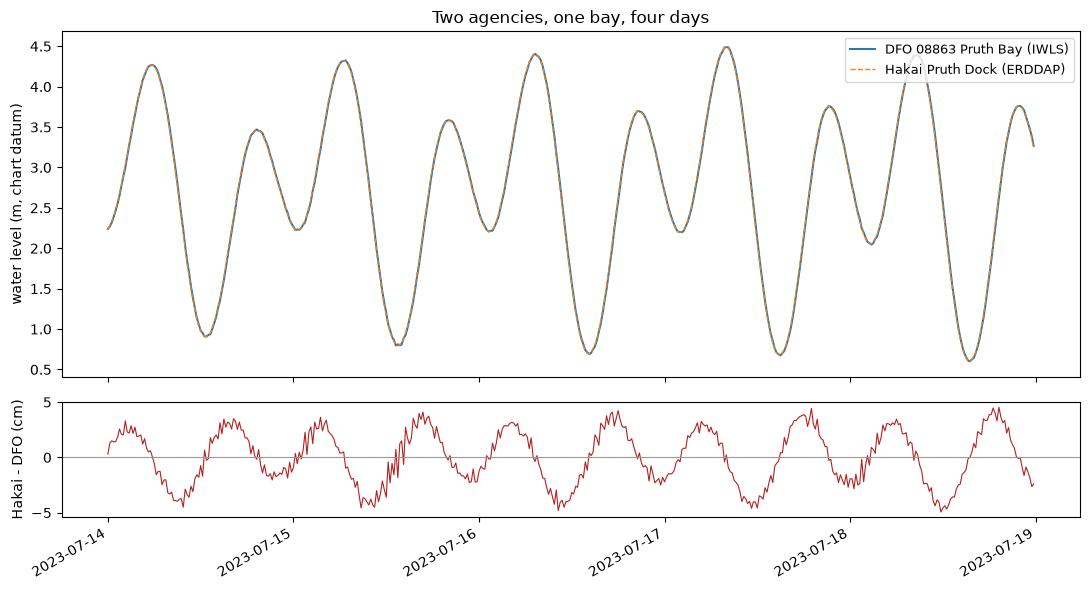

In [32]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True,
                       gridspec_kw={"height_ratios": [3, 1]})
w = slice("2023-07-14", "2023-07-18")
ax[0].plot(dfo[w].index, dfo[w].values, lw=1.4, label="DFO 08863 Pruth Bay (IWLS)")
ax[0].plot(hak[w].index, hak[w].values, lw=1.0, ls="--",
           label="Hakai Pruth Dock (ERDDAP)")
ax[0].set_ylabel("water level (m, chart datum)")
ax[0].legend(loc="upper right", fontsize=9)
ax[0].set_title("Two agencies, one bay, four days")
ax[1].plot((hak - dfo)[w].index, (hak - dfo)[w].values * 100, lw=0.8, color="firebrick")
ax[1].axhline(0, color="0.6", lw=0.8)
ax[1].set_ylabel("Hakai - DFO (cm)")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

Zero lag, a mean offset of a fraction of a millimetre, and 2.4 cm of scatter that is visibly tidal
in structure — largest around the steep parts of the curve, which is what a small timing or
response-time difference between two pressure sensors looks like. Both series are on chart datum
(DFO says so in the node's `datum` attribute; Hakai publishes no datum at all, and this comparison
is how I learned it uses the same one).

I would not call these two records fully independent — a gauge in Pruth Bay may well be the same
physical installation reported through two paths — but they are not the same *numbers*: the
difference is structured, not zero, so at minimum the processing chains differ. Either way, the
agreement means the datum and the clock came through both adapters intact. This is the check I
would want before trusting any cross-agency join, and it is the strongest evidence in this notebook
that the library's core promise holds.

## 11. Air, water, and the thermal lag of a bay

Now something the join was actually for. The mooring sits 3.1 km up the bay from the dock: one
instrument in the ocean, one in the atmosphere, same institute. How much of the daily air-temperature swing reaches the water, and how late?

Both are on the hourly grid. Remove everything slower than a day with a 25-hour centred mean, which
leaves the diurnal band.

In [33]:
air = H.airtemp_avg.dropna()
sea = H.sea_water_temperature.dropna()
common = air.index.intersection(sea.index)
air, sea = air[common], sea[common]

band = lambda s: s - s.rolling(25, center=True, min_periods=25).mean()
air_d, sea_d = band(air), band(sea)
ok = air_d.notna() & sea_d.notna()

dk = tree["/in_situ/erddap/hakai/HakaiPruthDockProvisional"].dataset
mr = tree["/in_situ/erddap/hakai/HakaiPruthMooringProvisional"].dataset
print(f"dock to mooring             "
      f"{great_circle_km(float(dk.latitude), float(dk.longitude), float(mr.latitude), float(mr.longitude)):.1f} km")
print(f"hours compared              {int(ok.sum())}")
print(f"monthly mean air            {air.mean():.2f} degC")
print(f"monthly mean surface water  {sea.mean():.2f} degC")
print(f"diurnal sd, air             {air_d[ok].std():.3f} degC")
print(f"diurnal sd, water           {sea_d[ok].std():.3f} degC")
print(f"damping ratio water/air     {sea_d[ok].std() / air_d[ok].std():.3f}")

dock to mooring             3.1 km
hours compared              721
monthly mean air            13.97 degC
monthly mean surface water  14.68 degC
diurnal sd, air             1.542 degC
diurnal sd, water           0.435 degC
damping ratio water/air     0.282


water lags air by 5 h   (r = 0.550);  r at zero lag = 0.200


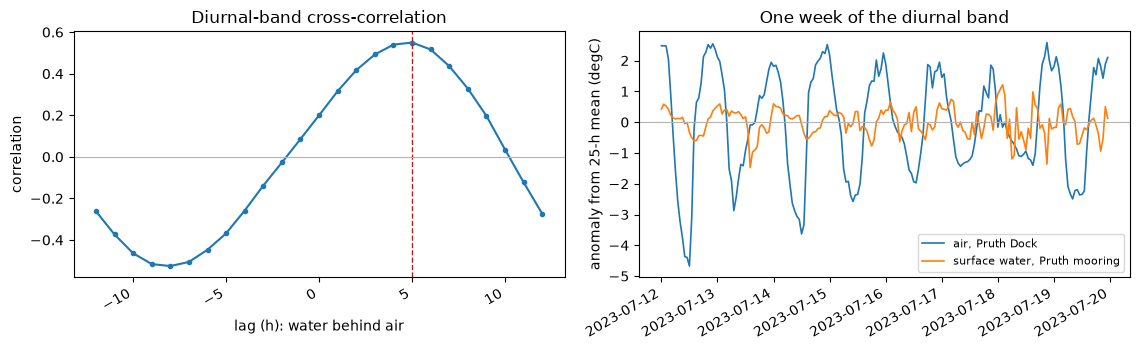

In [34]:
x, y = air_d[ok].to_numpy(), sea_d[ok].to_numpy()
lags = np.arange(-12, 13)
rr = []
for L in lags:
    p, q = (x[-L:], y[:len(y) + L]) if L < 0 else ((x[:len(x) - L], y[L:]) if L > 0 else (x, y))
    rr.append(np.corrcoef(p, q)[0, 1])
rr = np.array(rr)
best = lags[rr.argmax()]
print(f"water lags air by {best} h   (r = {rr.max():.3f});  r at zero lag = {rr[lags == 0][0]:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.6))
ax[0].plot(lags, rr, marker="o", ms=3)
ax[0].axvline(best, color="firebrick", ls="--", lw=1)
ax[0].axhline(0, color="0.7", lw=0.8)
ax[0].set_xlabel("lag (h): water behind air"); ax[0].set_ylabel("correlation")
ax[0].set_title("Diurnal-band cross-correlation")

w = slice("2023-07-12", "2023-07-19")
ax[1].plot(air_d[w].index, air_d[w].values, lw=1.2, label="air, Pruth Dock")
ax[1].plot(sea_d[w].index, sea_d[w].values, lw=1.2, label="surface water, Pruth mooring")
ax[1].axhline(0, color="0.7", lw=0.8)
ax[1].set_ylabel("anomaly from 25-h mean (degC)")
ax[1].legend(fontsize=8); ax[1].set_title("One week of the diurnal band")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

The surface layer keeps about 28 percent of the air's daily amplitude and runs 5 hours behind it.
Both numbers are physically sensible for a sheltered bay on this coast: water's heat capacity plus
the depth over which the daily heating is mixed damps the signal, and the lag is set by how long
that column takes to respond. At zero lag the correlation is only 0.20 — so anyone joining these two
series without checking the phase would conclude air and water temperature are barely related,
which is the wrong answer for the right-looking reason.

The monthly means run the other way: the water is warmer than the air on average. That is a bay
integrating a summer's worth of heating while the air over it is ventilated by onshore wind off a
cold Pacific.

## 12. Does the federal lightstation stand in for the observatory?

The practical question behind all this: if I had no Hakai record, would ECCC's Addenbroke Island
lightstation do? It is the nearest federal air-temperature record, 19 km east — but on the inside
of the archipelago, in Fitz Hugh Sound, while Pruth Dock faces Kwakshua Channel and the open
Pacific.

To compare fairly I have to build Hakai's day the way ECCC builds its own: local calendar days, and
a "mean" that is really the mid-range.

In [35]:
dock = tree["/in_situ/erddap/hakai/HakaiPruthDockProvisional"].dataset
hk = pd.Series(dock.airtemp_avg.values, index=pd.to_datetime(dock.time.values)).dropna()
hk.index = hk.index.tz_localize("UTC").tz_convert("America/Vancouver")

g = hk.groupby(hk.index.date)
hak_daily = pd.DataFrame({"n": g.size(), "hakai_mean24": g.mean(),
                          "hakai_max": g.max(), "hakai_min": g.min()})
hak_daily = hak_daily[hak_daily.n == 288]          # complete local days only
hak_daily["hakai_midrange"] = (hak_daily.hakai_max + hak_daily.hakai_min) / 2

ecc_daily = pd.DataFrame({"eccc_mean": e.air_temperature.values,
                          "eccc_max": e.air_temperature_max.values,
                          "eccc_min": e.air_temperature_min.values},
                         index=pd.to_datetime(e.time.values).date)

J = hak_daily.join(ecc_daily, how="inner").dropna()
print(f"complete paired local days: {len(J)}")
print()
for a, b, label in [("hakai_mean24", "eccc_mean", "24-h mean vs ECCC mean"),
                    ("hakai_midrange", "eccc_mean", "(max+min)/2 vs ECCC mean"),
                    ("hakai_max", "eccc_max", "daily maximum"),
                    ("hakai_min", "eccc_min", "daily minimum")]:
    d = J[a] - J[b]
    print(f"{label:28s} r = {J[a].corr(J[b]):.3f}   bias = {d.mean():+.2f} degC   "
          f"RMS = {np.sqrt((d ** 2).mean()):.2f} degC")

complete paired local days: 30

24-h mean vs ECCC mean       r = 0.703   bias = -2.46 degC   RMS = 2.64 degC
(max+min)/2 vs ECCC mean     r = 0.664   bias = -2.47 degC   RMS = 2.76 degC
daily maximum                r = 0.549   bias = -3.08 degC   RMS = 3.45 degC
daily minimum                r = 0.818   bias = -1.81 degC   RMS = 2.22 degC


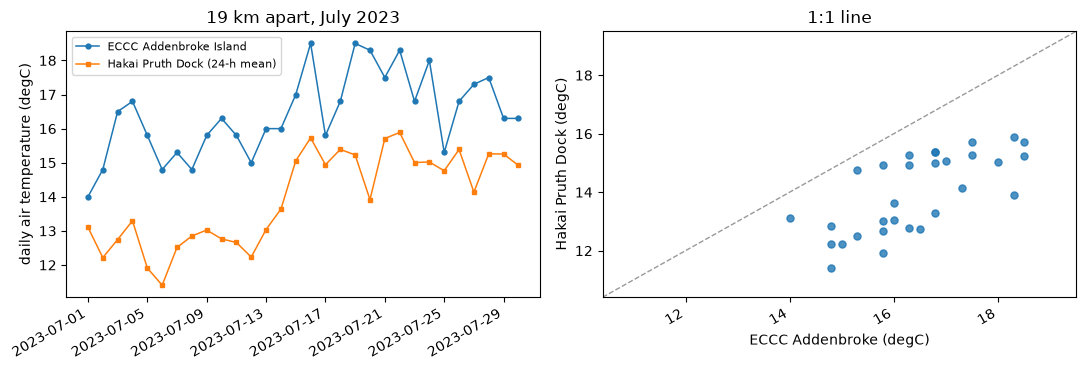

In [36]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].plot(J.index, J.eccc_mean, marker="o", ms=3.5, lw=1.1, label="ECCC Addenbroke Island")
ax[0].plot(J.index, J.hakai_mean24, marker="s", ms=3.5, lw=1.1, label="Hakai Pruth Dock (24-h mean)")
ax[0].set_ylabel("daily air temperature (degC)")
ax[0].legend(fontsize=8); ax[0].set_title("19 km apart, July 2023")

lim = [min(J.hakai_mean24.min(), J.eccc_mean.min()) - 1,
       max(J.hakai_mean24.max(), J.eccc_mean.max()) + 1]
ax[1].scatter(J.eccc_mean, J.hakai_mean24, s=26, alpha=0.8)
ax[1].plot(lim, lim, color="0.6", lw=1, ls="--")
ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel("ECCC Addenbroke (degC)"); ax[1].set_ylabel("Hakai Pruth Dock (degC)")
ax[1].set_title("1:1 line")
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

No, it would not do. Every point sits below the 1:1 line: Pruth Dock runs about 2.5 degC cooler than
Addenbroke Island in July, the daily maxima differ by 3 degC, and day-to-day correlation is 0.70 on
the means and only 0.55 on the maxima. The minima track best (r = 0.82, bias -1.8 degC), which fits —
overnight the whole archipelago relaxes toward the same marine air mass, and it is daytime heating
that separates a sensor over water in a channel from a lightstation on the sheltered side.

This is why `drop_correlated()` was right to keep both columns. They are the same *variable* and
not the same *measurement*, and at this site substituting one for the other would put a 2.5 degC
bias into anything downstream — larger than most of the signals a nearshore ecology study is
chasing.

It is also the honest answer to the question this notebook opened with. The integration works; what
it buys you is the ability to see, in one table, that the federal record 19 km away is not a
substitute for the observatory on your beach.

## 13. Save it, and attribute it

In [37]:
omnisea.to_netcdf(tree, "calvert_island.nc")

import xarray as xr
reopened = xr.open_datatree("calvert_island.nc")
print("group structure round-tripped:")
for n in reopened.subtree:
    if n.dataset.data_vars:
        print("  ", n.path)

group structure round-tripped:
   /predictions/tides_hilo/08860
   /predictions/tides_hilo/08865
   /predictions/tides_hilo/08912
   /in_situ/tides/08863
   /in_situ/weather_daily/1060080
   /in_situ/erddap/hakai/HakaiPruthDockProvisional
   /in_situ/erddap/hakai/HakaiPruthMooringProvisional


In [38]:
print(omnisea.citation(tree))

Data were retrieved with omnisea 0.1.0 on 2026-08-28T12:28:31+00:00 from 3 source(s) across 7 station(s), covering 2023-07-01 to 2023-08-01.

  Fisheries and Oceans Canada / Canadian Hydrographic Service — dfo_tides (4 station(s), 2023-07-01 to 2023-08-01): Pruth Bay (08863), Addenbroke Island (08860), Adams Harbour (08865), Spider Island (08912). Licence: Fisheries and Oceans Canada — Open Government Licence – Canada. Terms: https://open.canada.ca/en/open-government-licence-canada
  Environment and Climate Change Canada / Meteorological Service of Canada — eccc_climate_daily (1 station(s), 2023-07-01 to 2023-08-01): ADDENBROKE ISLAND (1060080). Licence: Environment and Climate Change Canada — Open Government Licence – Canada. Terms: https://eccc-msc.github.io/open-data/licence/readme_en/
  Hakai Institute — erddap_tabledap (1 station(s), 2023-07-01 to 2023-08-01): Water Level and Weather Station Time Series, Pruth Bay, Kwakshua Channel, Central Coast, BC, Canada (Provisional) (HakaiPr

Three institutions, three licences, and the exact endpoints available via
`citation(tree, include_urls=True)` — which matters for the Hakai datasets, whose contents are
marked provisional and will be revised. (The "Terms" link on the Hakai block points at NOAA
CoastWatch's ERDDAP information page — a generic ERDDAP default that has nothing to do with the
Hakai Institute, and not what you would want pasted into a methods section.)

**One line of that block is wrong and worth flagging.** The closing note says
`dfo_tides/08863` "matched but returned no rows". Station 08863 is Pruth Bay: it is named in the
DFO block above as a contributing station, it is the 2,974-point series this whole notebook is built
on, and it is the record that agreed with Hakai's gauge to 2.4 cm. What actually happened is that
DFO exposes two series per station — observed water level and predicted extrema — and 08863 has no
prediction series; the bookkeeping appears to be per-station rather than per-series, so an empty
second series is reported as an empty station. `dfo_tides/08866` (Starfish Island) in the same note
*is* genuinely empty.

That matters because this note is the feature that is supposed to stop you publishing a partial
pull without noticing. Crying wolf about the principal station trains you to ignore it.

## What I would tell a colleague

**It works, and the numbers are right.** Three organizations, three protocols, one call; every value
I checked against the upstream API matched to the last decimal; the two independent water-level
records agree to 2.4 cm at zero lag. The time-zone handling is better than mine would have been —
ECCC's local calendar days are converted correctly and the seven-hour gap at the start of the hourly
matrix is the proof. `align()`'s per-variable rules (nearest for instantaneous, backward-within-
interval for summaries) and the audit trail in `omnisea_aggregation` are the parts I would miss most
if I went back to writing this by hand.

**Three things to know before you rely on it.**

1. *A `TimeSeriesProfile` is silently flattened.* Fetch a multi-depth mooring without `depth=` and
   you get one arbitrary depth per timestamp — over 90 percent of the data gone, and what remains is a
   scramble that still looks like a time series. Always pass `depth=[low, high]`, and check the
   depths you got back.
2. *Discovery cannot see a dataset whose publisher left the extents blank*, which at Calvert Island
   means Hakai's own flagship records. Know your station ids, and use `erddap_datasets=`.
3. *`distance_km` is meaningless for ERDDAP rows.* Everything is 0.0 and the reported coordinates can
   be a global average. Use the sweep to find institutions, not platforms.

**And two smaller ones:** `catalog.frame` and `catalog.matches` are in different orders, so recover
the server name by joining on `station_id`; and read `citation()`'s "returned no rows" note against
`describe()` before believing it.